In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
filepath = "data/gen9ou-0.txt"
#define filepath for future use

In [4]:
with open(filepath, 'r') as f:
    lines = f.readlines()

    data_lines = [line.strip() for line in lines if '|' in line and "Rank" 
    not in line and "---" not in line]
    #filters out where data actually begins

    #split by pipe
    rows = [line.split('|')[1:-1] for line in data_lines]
    rows = [[cell.strip() for cell in row] for row in rows]

    columns = ["Rank", "Pokemon", "Usage %", "Raw", "Raw %", "Real", "Real %"]

    stats_df = pd.DataFrame(rows, columns=columns)
    #df created

    #convert rows to numeric
    stats_df["Rank"] = stats_df["Rank"].astype(int)
    stats_df["Usage %"] = stats_df["Usage %"].str.replace('%', '').astype(float)
    stats_df["Raw"] = stats_df["Raw"].astype(int)
    stats_df["Raw %"] = stats_df["Raw %"].str.replace('%', '').astype(float)
    stats_df["Real"] = stats_df["Real"].astype(int)
    stats_df["Real %"] = stats_df["Real %"].str.replace('%', '').astype(float)



In [5]:
stats_df.head()

,Rank,Pokemon,Usage %,Raw,Raw %,Real,Real %
0,1,Great Tusk,25.92623,483843,25.926,382714,25.879
1,2,Kingambit,17.62130,328854,17.621,224335,15.170
2,3,Gholdengo,17.18191,320654,17.182,246630,16.677
3,4,Dragapult,15.33391,286166,15.334,222130,15.021
4,5,Dragonite,14.49993,270602,14.500,198376,13.414


In [6]:
stats_df = stats_df.set_index("Rank")
stats_df_cleaned = stats_df[['Pokemon', 'Usage %']]
stats_df_cleaned

#filter out only rank and usage stats. those are the only important things to me

,Pokemon,Usage %
Rank,,
1,Great Tusk,25.92623
2,Kingambit,17.62130
3,Gholdengo,17.18191
4,Dragapult,15.33391
5,Dragonite,14.49993
...,...,...
748,Chimchar,0.00005
749,Hoothoot,0.00005
750,Sandshrew-Alola,0.00005


In [7]:
role_map = {
    "Great Tusk": "Hazard Removal",
    "Kingambit": "Sweeper",
    "Gholdengo": "Wallbreaker",
    "Dragapult": "Pivot",
    "Dragonite": "Sweeper",
    "Ogerpon-Wellspring": "Wallbreaker",
    "Iron Valiant": "Sweeper",
    "Zamazenta": "Sweeper",
    "Slowking-Galar": "Pivot",
    "Corviknight": "Pivot",
    "Gliscor": "Wall",
    "Raging Bolt": "Wallbreaker",
    "Hatterene": "Hazard Removal",
    "Landorus-Therian": "Pivot",
    "Cinderace": "Pivot",
    "Iron Treads": "Hazard Lead",
    "Alomomola": "Pivot",
    "Glimmora": "Hazard Lead",
    "Kyurem": "Wallbreaker",
    "Ceruledge": "Sweeper",
    "Samurott-Hisui": "Hazard Lead",
    "Scizor": "Pivot",
    "Ting-Lu": "Wall",
    "Darkrai": "Sweeper",
    "Rillaboom": "Pivot",
    "Garganacl": "Wall",
    "Iron Moth": "Sweeper",
    "Zapdos": "Pivot",
    "Pecharunt": "Pivot",
    "Walking Wake": "Wallbreaker",
    "Garchomp": "Hazard Stack",
    "Tyranitar": "Wallbreaker",
    "Heatran": "Wallbreaker",
    "Primarina": "Pivot",
    "Clefable": "   ",
    "Moltres": "Pivot",
    "Enamorus": "Sweeper",
    "Deoxys-Speed": "Sweeper",
    "Meowscarada": "Pivot",
    "Excadrill": "Sweeper",
    "Weezing-Galar": "Pivot",
    "Iron Crown": "Pivot",
    "Torkoal": "Weather Setter",
    "Pelipper": "Weather Setter",
    "Dondozo": "Wall",
    "Toxapex": "Pivot",
    "Tornadus-Therian": "Pivot",
    "Hydrapple": "Wallbreaker",
    "Clodsire": "Wall",
    "Greninja": "Sweeper",
    "Blaziken": "Sweeper",
    "Ninetales-Alola": "Weather Setter",
    "Ursaluna": "Wallbreaker",
    "Serperior": "Sweeper",
    "Araquanid": "Hazard Lead",
    "Hoopa-Unbound": "Wallbreaker",
    "Blissey": "Wall",
    "Weavile": "Wallbreaker",
    "Ninetales": "Weather Setter",
    "Skeledirge": "Wall",
    "Lokix": "Wallbreaker",
    "Rotom-Wash": "Pivot",
    "Quaquaval": "Sweeper",
    "Latios": "Wallbreaker",
    "Sinistcha": "Utility",
    "Venusaur": "Sweeper",
    "Tinkaton": "Utility",
    "Grimmsnarl": "Utility",
    "Iron Hands": "Pivot",
    "Ribombee": "Hazard Lead",
    "Skarmory": "Wall",
    "Volcanion": "Wallbreaker",
    "Gengar": "Sweeper",
    "Goodra-Hisui": "Wall",
    "Barraskewda": "Sweeper",
    "Arcanine-Hisui": "Wallbreaker",
    "Mimikyu": "Sweeper",
    "Ogerpon-Cornerstone": "Sweeper",
    "Zoroark-Hisui": "Wallbreaker",
    "Hawlucha": "Sweeper",
    "Ogerpon": "Wallbreaker",
    "Umbreon": "Wall",
    "Keldeo": "Wallbreaker",
    "Metagross": "Wallbreaker",
    "Maushold": "Hazard Removal",
    "Polteageist": "Sweeper",
    "Iron Boulder": "Sweeper",
    "Incineroar": "Pivot",
    "Indeedee": "Utility",
    "Moltres-Galar": "Sweeper",
    "Slither Wing": "Wallbreaker",
    "Azumarill": "Wallbreaker",
    "Thundurus-Therian": "Sweeper",
    "Latias": "Sweeper",
    "Gyarados": "Sweeper",
    "Kommo-o": "Sweeper",
    "Hydreigon": "Wallbreaker",
    "Cresselia": "Wall",
    "Cloyster": "Sweeper",
    "Mandibuzz": "Pivot",
    "Comfey": "Sweeper",
    "Galvantula": "Hazard Lead",
    "Lilligant-Hisui": "Sweeper",
    "Gardevoir": "Wallbreaker",
    "Conkeldurr": "Wallbreaker",
    "Charizard": "Sweeper",
    "Talonflame": "Pivot",
    "Haxorus": "Sweeper",
    "Chesnaught": "Hazard Stack",
    "Blastoise": "Hazard Removal",
    "Jolteon": "Pivot",
    "Salamence": "Sweeper",
    "Kingdra": "Sweeper",
    "Mamoswine": "Wallbreaker",
    "Espeon": "Utility",
    "Okidogi": "Wallbreaker",
    "Milotic": "Wall",
    "Sandy Shocks": "Hazard Stack",
    "Magnezone": "Wallbreaker",
    "Manaphy": "Sweeper",
    "Amoonguss": "Wall",
    "Chandelure": "Wallbreaker",
    "Kleavor": "Hazard Lead",
    "Forretress": "Hazard Removal",
    "Armarouge": "Wallbreaker",
    "Jirachi": "Pivot",
    "Bronzong": "Wall",
    "Ditto": "Utility",
    "Toxicroak": "Sweeper",
    "Empoleon": "Hazard Removal",
    "Lucario": "Sweeper",
    "Infernape": "Pivot",
    "Whimsicott": "Utility",
    "Mew": "Utility",
    "Slowking": "Pivot",
    "Fezandipiti": "Pivot",
    "Muk-Alola": "Wall",
    "Snorlax": "Wall",
    "Chansey": "Wall",
    "Pawmot": "Wallbreaker",
    "Swampert": "Pivot",
    "Gastrodon": "Wall",
    "Reuniclus": "Sweeper",
    "Breloom": "Wallbreaker",
    "Salazzle": "Sweeper",
    "Gallade": "Sweeper",
    "Porygon2": "Wall",
    "Porygon-Z": "Sweeper",
    "Tentacruel": "Hazard Removal",
    "Sylveon": "Wall",
    "Hippowdon": "Weather Setter",
    "Regidrago": "Wallbreaker",
    "Krookodile": "Pivot",
    "Torterra": "Sweeper",
    "Zapdos-Galar": "Sweeper",
    "Sableye": "Utility",
    "Deoxys-Defense": "Hazard Lead",
    "Crawdaunt": "Wallbreaker",
    "Quagsire": "Wall",
    "Vaporeon": "Wall",
    "Toxtricity": "Wallbreaker",
    "Sceptile": "Sweeper",
    "Noivern": "Pivot",
    "Kilowattrel": "Pivot",
    "Bisharp": "Sweeper",
    "Donphan": "Hazard Removal",
    "Basculegion": "Sweeper",
    "Thundurus": "Sweeper",
    "Staraptor": "Wallbreaker",
    "Vileplume": "Wall",
    "Frosmoth": "Sweeper",
    "Pincurchin": "Utility",
    "Feraligatr": "Sweeper",
    "Rotom-Heat": "Pivot",
    "Decidueye-Hisui": "Wallbreaker",
    "Ambipom": "Pivot",
    "Klefki": "Utility",
    "Politoed": "Weather Setter",
    "Slowbro": "Pivot",
    "Arcanine": "Pivot",
    "Iron Jugulis": "Sweeper",
    "Vikavolt": "Wallbreaker",
    "Eelektross": "Pivot",
    "Diancie": "Utility",
    "Smeargle": "Hazard Lead",
    "Inteleon": "Sweeper",
    "Lycanroc-Dusk": "Hazard Lead",
    "Cetitan": "Sweeper",
    "Malamar": "Sweeper",
    "Overqwil": "Hazard Stack",
    "Grafaiai": "Utility",
    "Goodra": "Wall",
    "Heracross": "Wallbreaker",
    "Typhlosion-Hisui": "Wallbreaker",
    "Scream Tail": "Utility",
    "Cyclizar": "Pivot",
    "Tsareena": "Hazard Removal",
    "Pikachu": "Unviable",
    "Yanmega": "Sweeper",
    "Cinccino": "Sweeper",
    "Mienshao": "Pivot",
    "Dragalge": "Wallbreaker"

}

with_roles = stats_df_cleaned.copy()
with_roles['Role'] = with_roles['Pokemon'].map(role_map)

with_roles.loc[with_roles['Role'].isna() & (with_roles['Usage %'] < 0.3), 'Role'] = 'Unviable'


#yes these pokemon have multiple sets. dd kyurem is a thing and deadly. we are 
#just using the most common ones for now
with_roles


,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,25.92623,Hazard Removal
2,Kingambit,17.62130,Sweeper
3,Gholdengo,17.18191,Wallbreaker
4,Dragapult,15.33391,Pivot
5,Dragonite,14.49993,Sweeper
...,...,...,...
748,Chimchar,0.00005,Unviable
749,Hoothoot,0.00005,Unviable
750,Sandshrew-Alola,0.00005,Unviable


In [12]:
in_ou = ["Alomomola", "Ceruledge", "Cinderace", "Clefable", "Darkrai", "Deoxys-Speed", "Dondozo"
         "Dragapult", "Dragonite", "Enamorus", "Garganacl", "Gholdengo", "Glimmora", "Gliscor", "Great Tusk",
         "Hatterene", "Heatran", "Iron Crown", "Iron Moth", "Iron Treads", "Iron-Valiant", "Kingambit", "Kyurem"
         "Moltres", "Ogerpon-Wellspring", "Pecharunt", "Primarina", "Raging Bolt", "Rillaboom", "Samurott-Hisui", "Slowking-Galar"
         "Ting-Lu", "Tornadus-Therian", "Tyranitar", "Walking Wake", "Weezing-Galar", "Zamazenta", "Zapdos"]

#just snipping down to only pokemon in OU for some experimentation

ou_set = set(in_ou)
ou_df = with_roles[with_roles["Pokemon"].isin(ou_set)].copy()

ou_df

,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,25.92623,Hazard Removal
2,Kingambit,17.62130,Sweeper
3,Gholdengo,17.18191,Wallbreaker
5,Dragonite,14.49993,Sweeper
6,Ogerpon-Wellspring,13.92931,Wallbreaker
8,Zamazenta,12.72319,Sweeper
11,Gliscor,11.27680,Wall
12,Raging Bolt,10.99329,Wallbreaker
13,Hatterene,10.94126,Hazard Removal


In [13]:
gen_origin = {
    "Alomomola": 5,
    "Ceruledge": 9,
    "Cinderace": 8,
    "Clefable": 1,
    "Darkrai": 4,
    "Deoxys-Speed": 3,
    "Dondozo": 9,
    "Dragapult": 8,
    "Dragonite": 1,
    "Enamorus": 8,
    "Garganacl": 9,
    "Gholdengo": 9,
    "Glimmora": 9,
    "Gliscor": 2,
    "Great Tusk": 9,
    "Hatterene": 8,
    "Heatran": 4,
    "Iron Crown": 9,
    "Iron Moth": 9,
    "Iron Treads": 9,
    "Iron-Valiant": 9,
    "Kingambit": 9,
    "Kyurem": 5,
    "Moltres": 1,
    "Ogerpon-Wellspring": 9,
    "Pecharunt": 9,
    "Primarina": 7,
    "Raging Bolt": 9,
    "Rillaboom": 8,
    "Samurott-Hisui": 5,
    "Slowking-Galar": 2,
    "Ting-Lu": 9,
    "Tornadus-Therian": 5,
    "Tyranitar": 2,
    "Walking Wake": 9,
    "Weezing-Galar": 1,
    "Zamazenta": 8,
    "Zapdos": 1,
}

ou_df['Generation'] = ou_df['Pokemon'].map(gen_origin)
ou_df

,Pokemon,Usage %,Role,Generation
Rank,,,,
1,Great Tusk,25.92623,Hazard Removal,9
2,Kingambit,17.62130,Sweeper,9
3,Gholdengo,17.18191,Wallbreaker,9
5,Dragonite,14.49993,Sweeper,1
6,Ogerpon-Wellspring,13.92931,Wallbreaker,9
8,Zamazenta,12.72319,Sweeper,8
11,Gliscor,11.27680,Wall,2
12,Raging Bolt,10.99329,Wallbreaker,9
13,Hatterene,10.94126,Hazard Removal,8


Text(0.5, 1.0, 'Distribution of Pokemon in Gen 9 OU by Generation')

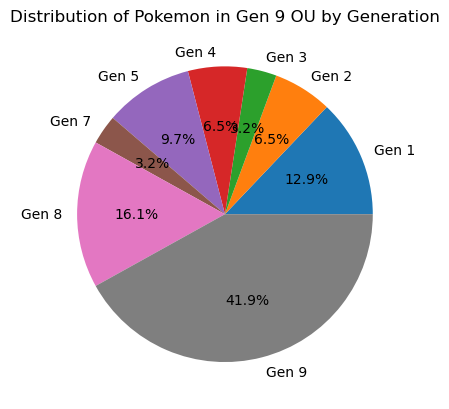

In [20]:
labels = [f"Gen {g}" for g in counts.index]
counts = ou_df["Generation"].value_counts().sort_index()

plt.pie(counts.values, labels=labels, autopct="%1.1f%%")
plt.title("Distribution of Pokemon in Gen 9 OU by Generation")

Perhaps unsurprisingly, Gen 9 has the most Pokemon in it's OU generation. Between all the paradoxes and monsters like Gholdengo, this is fairly expected. WHat is surprising is absolutely no Pokemon from Gen 6